In [1]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from Python_files import time_integration_functions as TST
# from python_files import TLM_tests as TT
from Python_files import ETLM as ETLMC
from Python_files import LETLM as LETLMC
from Python_files import IETLM as IETLMC
from Python_files import GETLM as GETLMC

torch.set_default_dtype(torch.float64)


In [26]:
# We will start by testing Crank-Nicolson
# Once the LETLM and IETLM have been updated add them into here

# The first step is to spin up the model, to do that we need to set the model parameters
#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.5 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.CN_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)
print(x_in)


100%|██████████| 999/999 [00:00<00:00, 19753.30it/s]

[tensor([[8.0000]]), tensor([[8.0000]])]


In [27]:
# We now need to generate the ensembles
# However, before we do this we need to know how many ensemble we need
# To calculate this we need to first specify what stencil members we need to sample
stencil_members_future_CN = [-2,-1,0,1]
stencil_members_current_CN = [-2,-1,0,1]
stencil_members_past_CN = []
stencil_members_large_CN = [stencil_members_future_CN, stencil_members_current_CN, stencil_members_past_CN]
ensemble_size_CN = len(stencil_members_future_CN) + len(stencil_members_current_CN) + len(stencil_members_past_CN) + 5

# Now that we know this we can generate our ensemble 
# We will now test out the ensemble generator 
stand_dev = 10**(-7)
# print(x_out)

Chi, Xi, X = GETLMC.GETLM_ensemble_generator(x_out[0],x_out[1], ensemble_size_CN, stand_dev, model,model_parameters)

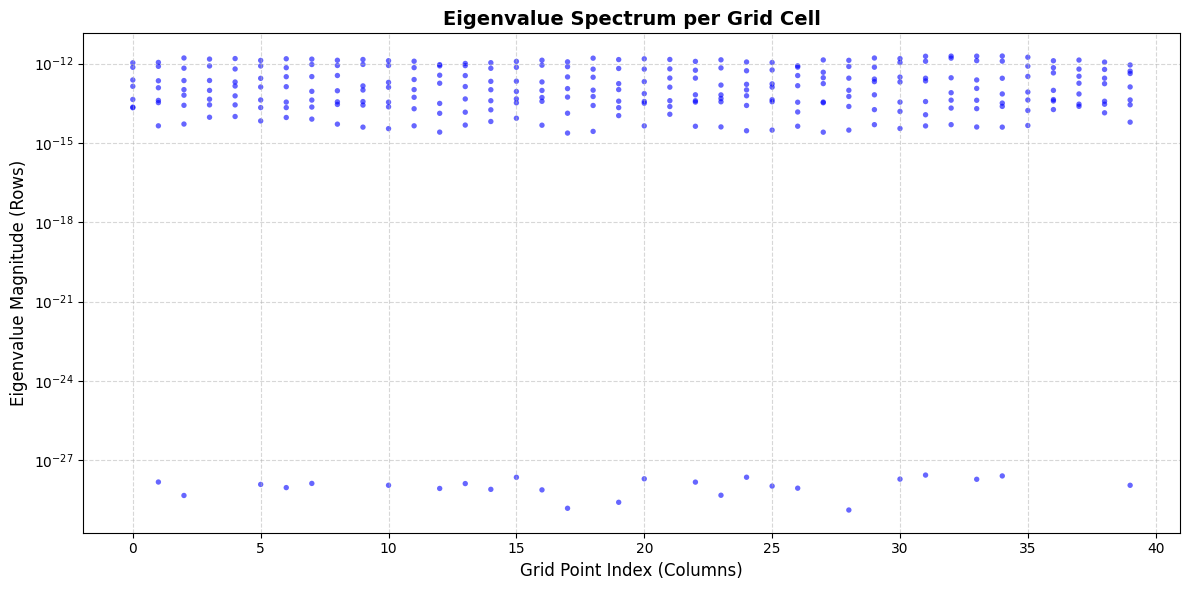

In [28]:
# We can now generate our GETLM 
k = 1 # number of zero eigenvalue eigenvalues

N_tilde, L_tilde, K_tilde = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k)

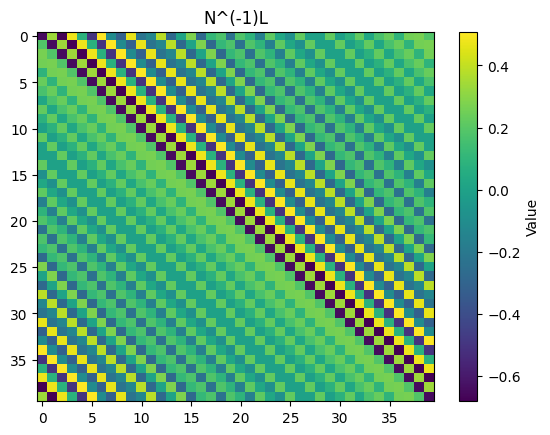

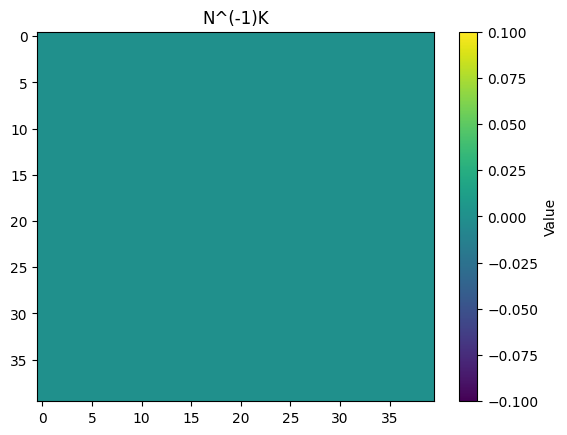

In [29]:
plt.imshow(torch.pinverse(N_tilde) @ L_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)L")
plt.show()
plt.imshow(torch.pinverse(N_tilde) @ K_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)K")
plt.show()

In [36]:
# We will now do Runge-Kutta 4

# The first step is to spin up the model, to do that we need to set the model parameters
#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.rk4_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)
print(x_in)



100%|██████████| 999/999 [00:00<00:00, 16472.89it/s]

[tensor([8.0000]), tensor([8.0000])]


In [37]:
# We now need to generate the ensembles
# However, before we do this we need to know how many ensemble we need
# To calculate this we need to first specify what stencil members we need to sample
stencil_members_future_RK4 = [0]
stencil_members_current_RK4 = [-8,-7,-6,5,-4,-3,-2,-1,0,1,2,3,4,5]
stencil_members_past_RK4 = []
stencil_members_large_RK4 = [stencil_members_future_RK4, stencil_members_current_RK4, stencil_members_past_RK4]
ensemble_size_RK4 = len(stencil_members_future_RK4) + len(stencil_members_current_RK4) + len(stencil_members_past_RK4) + 5

# Now that we know this we can generate our ensemble 
# We will now test out the ensemble generator 
stand_dev = 10**(-7)


Chi, Xi, X = GETLMC.GETLM_ensemble_generator(x_out[0],x_out[1], ensemble_size_RK4, stand_dev, model,model_parameters)

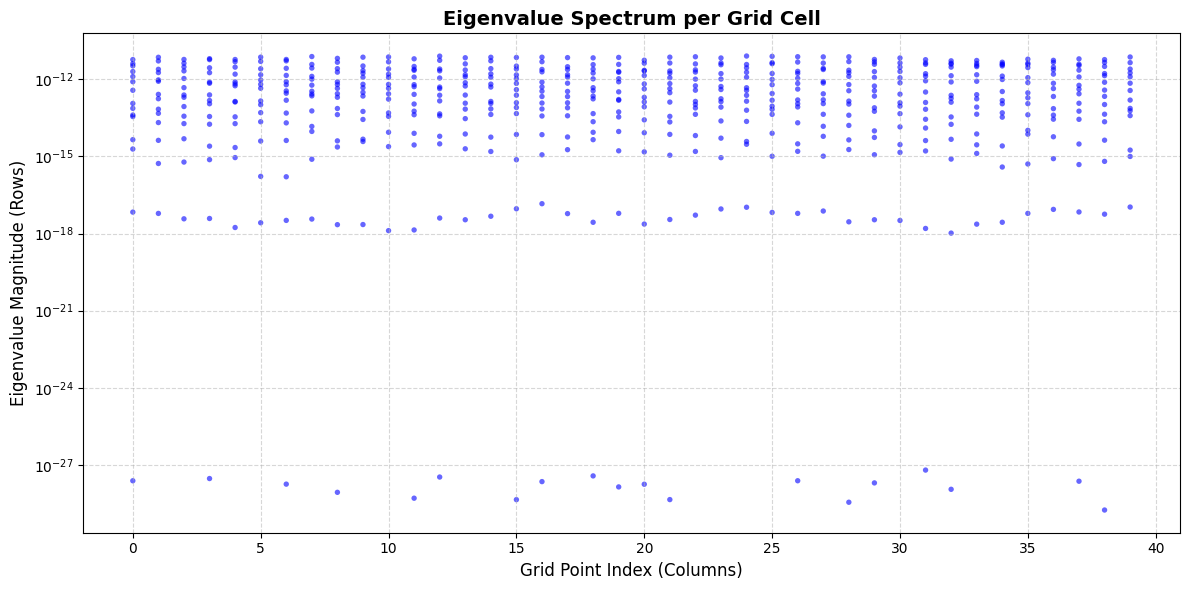

In [40]:
# We can now generate our GETLM 
k = 2 # number of zero eigenvalue eigenvalues

N_tilde, L_tilde, K_tilde = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_RK4, model_parameters, ensemble_size_RK4, k)

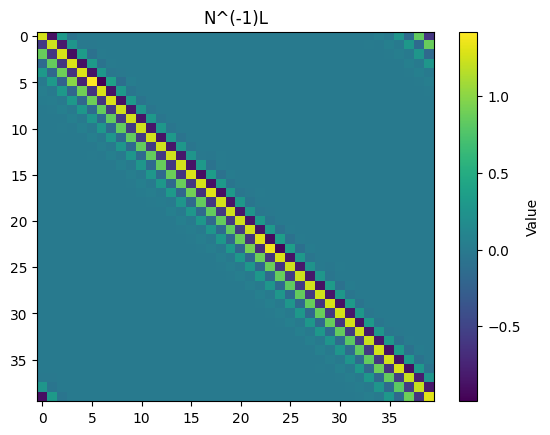

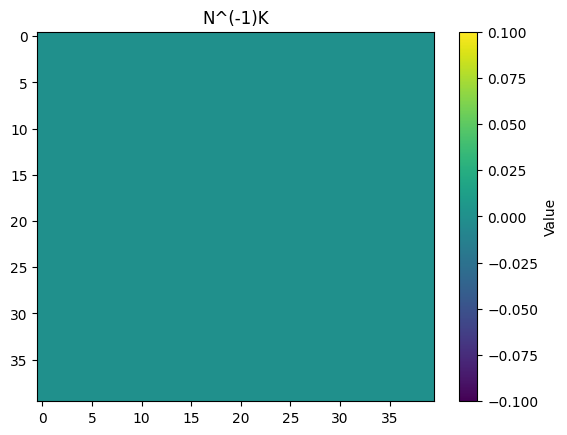

In [41]:
plt.imshow(torch.pinverse(N_tilde) @ L_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)L")
plt.show()
plt.imshow(torch.pinverse(N_tilde) @ K_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)K")
plt.show()

In [51]:
# We will now do Leapfrog

# The first step is to spin up the model, to do that we need to set the model parameters
#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.08 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.LF_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)
print(x_in)


100%|██████████| 999/999 [00:00<00:00, 39492.08it/s]

[tensor([8.0000]), tensor([8.0000])]


In [52]:
# We now need to generate the ensembles
# However, before we do this we need to know how many ensemble we need
# To calculate this we need to first specify what stencil members we need to sample
stencil_members_future_LF = [0]
stencil_members_current_LF = [-2,-1,0,1]
stencil_members_past_LF = [0]
stencil_members_large_LF = [stencil_members_future_LF, stencil_members_current_LF, stencil_members_past_LF]
ensemble_size_LF = len(stencil_members_future_LF) + len(stencil_members_current_LF) + len(stencil_members_past_LF) + 5

# Now that we know this we can generate our ensemble 
# We will now test out the ensemble generator 
stand_dev = 10**(-7)


Chi, Xi, X = GETLMC.GETLM_ensemble_generator(x_out[0],x_out[1], ensemble_size_LF, stand_dev, model,model_parameters)

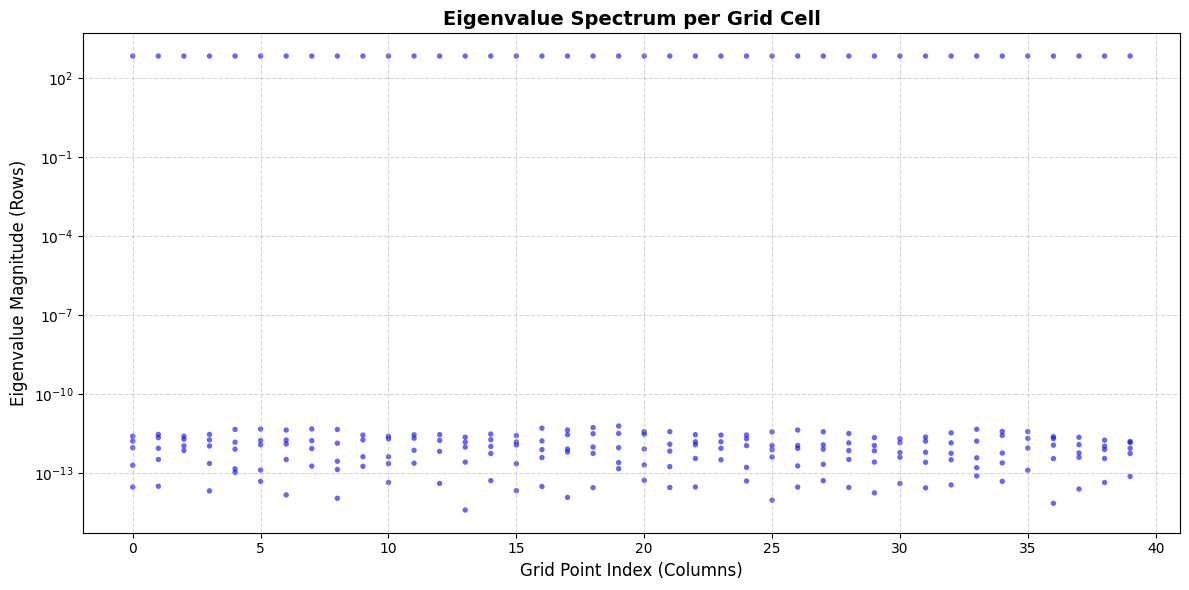

In [57]:
# We can now generate our GETLM 
k = 3 # number of zero eigenvalue eigenvalues

N_tilde, L_tilde, K_tilde = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_LF, model_parameters, ensemble_size_LF, k)

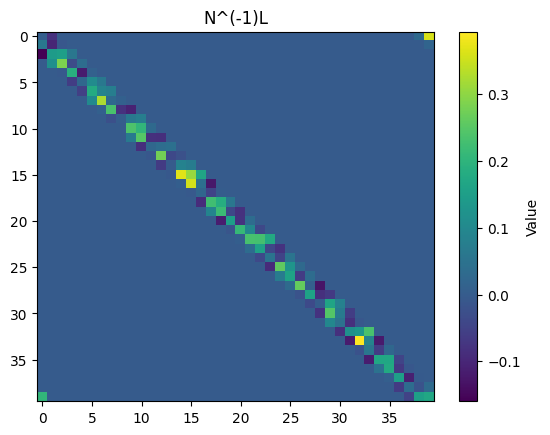

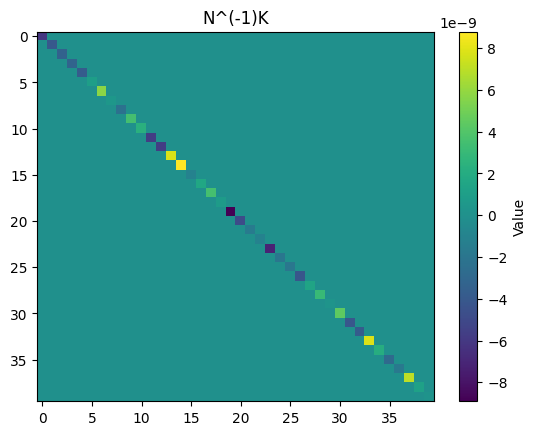

In [58]:
plt.imshow(torch.pinverse(N_tilde) @ L_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)L")
plt.show()
plt.imshow(torch.pinverse(N_tilde) @ K_tilde,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.title("N^(-1)K")
plt.show()